### Построение нейронной сети на табличных данных

In [97]:
import os
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tqdm import tqdm

import matplotlib.pyplot as plt

In [98]:
from notebooks.MLP.config import seed, batch_size, num_epochs, lr, test_size, target

Зафиксируем сиды (как в семинаре)

In [99]:
def seed_everything(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

seed_everything(42)

Загрузим нашим данные из файла

In [100]:
df = pd.read_csv("data/for_models/train_model_ready.csv")
df.head()

,Unnamed: 0,price,text_length,word_count,sentence_count,bullet_count,number_count,title_word_count,title_length,made_in_usa,...,is_beauty,is_pet,is_baby,is_household,is_premium,is_natural,log_price,log_pack_quantity,log_value,log_total_amount
0,0,4.89,91,19,1,0,3,11.0,55.0,0,...,0,0,0,0,0,0,1.587192,1.945910,4.290459,6.070738
1,1,13.12,511,81,1,5,11,11.0,65.0,0,...,0,0,0,0,0,0,2.574138,1.609438,3.496508,4.859812
2,2,1.97,328,61,2,5,9,15.0,76.0,0,...,1,0,0,0,0,0,0.678034,1.945910,2.517696,4.239887
3,3,30.34,1318,213,9,5,8,28.0,153.0,1,...,1,1,0,0,0,0,3.412467,0.693147,2.505526,2.505526
4,4,66.49,155,29,5,0,5,10.0,52.0,0,...,0,0,0,0,0,0,4.197052,0.693147,2.564949,2.564949


In [101]:
df.shape

(75000, 55)

In [102]:
df.columns.tolist()

['Unnamed: 0',
 'price',
 'text_length',
 'word_count',
 'sentence_count',
 'bullet_count',
 'number_count',
 'title_word_count',
 'title_length',
 'made_in_usa',
 'made_in_canada',
 'made_in_india',
 'made_in_italy',
 'made_in_mexico',
 'made_in_china',
 'made_in_turkey',
 'made_in_japan',
 'made_in_chile',
 'made_in_france',
 'made_in_spain',
 'made_in_thailand',
 'made_in_germany',
 'made_in_england',
 'made_in_sri_lanka',
 'made_in_indonesia',
 'made_in_australia',
 'made_in_new_zealand',
 'unit',
 'has_pack',
 'has_ingredients',
 'organic',
 'gluten_free',
 'vegan',
 'protein',
 'sugar_free',
 'nut_free',
 'dairy_free',
 'soy_free',
 'keto',
 'kosher',
 'halal',
 'brand_frequency',
 'is_food',
 'is_drink',
 'is_health',
 'is_beauty',
 'is_pet',
 'is_baby',
 'is_household',
 'is_premium',
 'is_natural',
 'log_price',
 'log_pack_quantity',
 'log_value',
 'log_total_amount']

In [11]:
df.dtypes

Unnamed: 0               int64
price                  float64
text_length              int64
word_count               int64
sentence_count           int64
bullet_count             int64
number_count             int64
title_word_count       float64
title_length           float64
made_in_usa              int64
made_in_canada           int64
made_in_india            int64
made_in_italy            int64
made_in_mexico           int64
made_in_china            int64
made_in_turkey           int64
made_in_japan            int64
made_in_chile            int64
made_in_france           int64
made_in_spain            int64
made_in_thailand         int64
made_in_germany          int64
made_in_england          int64
made_in_sri_lanka        int64
made_in_indonesia        int64
made_in_australia        int64
made_in_new_zealand      int64
unit                       str
has_pack                 int64
has_ingredients          int64
organic                  int64
gluten_free              int64
vegan   

In [103]:
df.select_dtypes(include="object").columns.tolist()

C:\Users\vladt\AppData\Local\Temp\ipykernel_8828\3671663173.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns.tolist()


['unit']

Из признаков удалим индексную колонку, price и log_price. Категориальный признак unit закодируем с помощью one-hot encoding. Пропуски заполним нулями.

In [104]:
y = df[target]
X = df.drop(columns=["Unnamed: 0", "price", "log_price"])

In [105]:
print("X before encoding:", X.shape)
print("y:", y.shape)

X before encoding: (75000, 52)
y: (75000,)


In [106]:
X.head()

,text_length,word_count,sentence_count,bullet_count,number_count,title_word_count,title_length,made_in_usa,made_in_canada,made_in_india,...,is_health,is_beauty,is_pet,is_baby,is_household,is_premium,is_natural,log_pack_quantity,log_value,log_total_amount
0,91,19,1,0,3,11.0,55.0,0,0,0,...,0,0,0,0,0,0,0,1.945910,4.290459,6.070738
1,511,81,1,5,11,11.0,65.0,0,0,0,...,0,0,0,0,0,0,0,1.609438,3.496508,4.859812
2,328,61,2,5,9,15.0,76.0,0,0,0,...,0,1,0,0,0,0,0,1.945910,2.517696,4.239887
3,1318,213,9,5,8,28.0,153.0,1,0,0,...,0,1,1,0,0,0,0,0.693147,2.505526,2.505526
4,155,29,5,0,5,10.0,52.0,0,0,0,...,0,0,0,0,0,0,0,0.693147,2.564949,2.564949


In [107]:
X["unit"] = X["unit"].fillna("unknown")
X = pd.get_dummies(X, columns=["unit"])
print("X after one-hot:", X.shape)

X after one-hot: (75000, 88)


In [108]:
X.head()

,text_length,word_count,sentence_count,bullet_count,number_count,title_word_count,title_length,made_in_usa,made_in_canada,made_in_india,...,unit_paper cupcake liners,unit_per package,unit_piece,unit_pouch,unit_product,unit_sq ft,unit_tea bags,unit_unit,unit_unknown,unit_ziplock bags
0,91,19,1,0,3,11.0,55.0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,511,81,1,5,11,11.0,65.0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,328,61,2,5,9,15.0,76.0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,1318,213,9,5,8,28.0,153.0,1,0,0,...,False,False,False,False,False,False,False,False,False,False
4,155,29,5,0,5,10.0,52.0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [109]:
X.isna().sum().sort_values(ascending=False).head(10)

brand_frequency     4335
title_length        4256
title_word_count    4256
log_total_amount     940
log_value            940
bullet_count           0
text_length            0
word_count             0
made_in_canada         0
made_in_india          0
dtype: int64

In [110]:
X = X.fillna(0)

print("Missing values:", X.isna().sum().sum())

Missing values: 0


In [111]:
X = X.astype("float32")
y = y.astype("float32")

In [112]:
X.shape

(75000, 88)

In [113]:
y.shape

(75000,)

In [114]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=test_size, random_state=seed)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (60000, 88)
X_valid: (15000, 88)
y_train: (60000,)
y_valid: (15000,)


In [115]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print("X_train_scaled:", X_train_scaled.shape)
print("X_valid_scaled:", X_valid_scaled.shape)

X_train_scaled: (60000, 88)
X_valid_scaled: (15000, 88)


In [116]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_valid_tensor.shape, y_valid_tensor.shape)

torch.Size([60000, 88]) torch.Size([60000, 1])
torch.Size([15000, 88]) torch.Size([15000, 1])


In [117]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

input_dim = X_train_tensor.shape[1]

print("Input dim:", input_dim)
print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))

Input dim: 88
Train batches: 59
Valid batches: 15


Сделаем первую mlp-модель

In [118]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [119]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MLPRegressor(input_dim).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

model

MLPRegressor(
  (model): Sequential(
    (0): Linear(in_features=88, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [120]:
X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

preds = model(X_batch)

print("X_batch:", X_batch.shape)
print("y_batch:", y_batch.shape)
print("preds:", preds.shape)

X_batch: torch.Size([1024, 88])
y_batch: torch.Size([1024, 1])
preds: torch.Size([1024, 1])


Функция для обучения одной эпохи

In [121]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(X_batch)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    avg_loss = total_loss / len(train_loader.dataset)

    return avg_loss

Функция для проверки на validation

In [122]:
def validate(model, valid_loader, criterion, device):
    model.eval()
    total_loss = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    avg_loss = total_loss / len(valid_loader.dataset)

    all_preds = np.vstack(all_preds).ravel()
    all_targets = np.vstack(all_targets).ravel()

    return avg_loss, all_preds, all_targets

Запускаем обучение:

In [123]:
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    valid_loss, valid_preds, valid_targets = validate(model, valid_loader, criterion, device)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"train loss: {train_loss:.4f} "
        f"valid loss: {valid_loss:.4f} "
    )

Epoch 1/10 train loss: 5.6778 valid loss: 1.9836 
Epoch 2/10 train loss: 1.3706 valid loss: 1.0871 
Epoch 3/10 train loss: 0.9923 valid loss: 0.9682 
Epoch 4/10 train loss: 0.9040 valid loss: 0.9219 
Epoch 5/10 train loss: 0.8622 valid loss: 0.8968 
Epoch 6/10 train loss: 0.8377 valid loss: 0.8793 
Epoch 7/10 train loss: 0.8219 valid loss: 0.8660 
Epoch 8/10 train loss: 0.8100 valid loss: 0.8589 
Epoch 9/10 train loss: 0.8021 valid loss: 0.8519 
Epoch 10/10 train loss: 0.7952 valid loss: 0.8455 


После обучения посмотрим метрики MAE, RMSE, R2 на log_price:

In [124]:
mae_log = mean_absolute_error(valid_targets, valid_preds)
rmse_log = mean_squared_error(valid_targets, valid_preds) ** 0.5
r2_log = r2_score(valid_targets, valid_preds)

print("MAE log:", mae_log)
print("RMSE log:", rmse_log)
print("R2 log:", r2_log)

MAE log: 0.7195717692375183
RMSE log: 0.9195150783935006
R2 log: 0.23703902959823608


Посмотрим также на метрики в обычной цене:

In [125]:
valid_price_true = np.exp(valid_targets)
valid_price_pred = np.exp(valid_preds)

mae_price = mean_absolute_error(valid_price_true, valid_price_pred)
rmse_price = mean_squared_error(valid_price_true, valid_price_pred) ** 0.5

print("MAE price:", mae_price)
print("RMSE price:", rmse_price)

MAE price: 14.641417503356934
RMSE price: 37.183514754945506


In [126]:
results = []

results.append({
    "model_name": "MLP_small",
    "architecture": "88 -> 64 -> 32 -> 1",
    "activation": "ReLU",
    "dropout": 0,
    "batchnorm": False,
    "loss": "MSELoss",
    "optimizer": "Adam",
    "mae_log": mae_log,
    "rmse_log": rmse_log,
    "r2_log": r2_log,
    "mae_price": mae_price,
    "rmse_price": rmse_price
})

pd.DataFrame(results)

,model_name,architecture,activation,dropout,batchnorm,loss,optimizer,mae_log,rmse_log,r2_log,mae_price,rmse_price
0,MLP_small,88 -> 64 -> 32 -> 1,ReLU,0,False,MSELoss,Adam,0.719572,0.919515,0.237039,14.641418,37.183515


Посмотрим на график

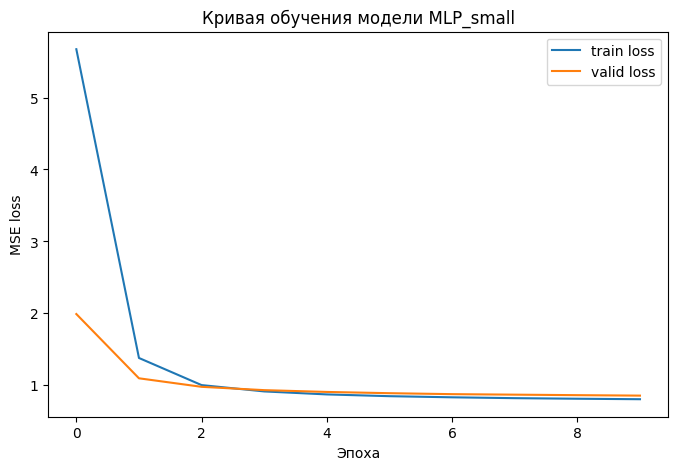

In [127]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train loss")
plt.plot(valid_losses, label="valid loss")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Кривая обучения модели MLP_small")
plt.legend()
plt.show()

Средняя:

In [128]:
class MLPMedium(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

In [129]:
model_medium = MLPMedium(input_dim).to(device)

criterion_medium = nn.MSELoss()
optimizer_medium = torch.optim.Adam(model_medium.parameters(), lr=lr)

model_medium

MLPMedium(
  (model): Sequential(
    (0): Linear(in_features=88, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [130]:
train_losses_medium = []
valid_losses_medium = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_medium, train_loader, criterion_medium, optimizer_medium, device)
    valid_loss, valid_preds_medium, valid_targets_medium = validate(model_medium, valid_loader, criterion_medium, device)

    train_losses_medium.append(train_loss)
    valid_losses_medium.append(valid_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"train loss: {train_loss:.4f} "
        f"valid loss: {valid_loss:.4f} "
    )

Epoch 1/10 train loss: 2.0317 valid loss: 0.8885 
Epoch 2/10 train loss: 0.8803 valid loss: 0.8445 
Epoch 3/10 train loss: 0.8276 valid loss: 0.8292 
Epoch 4/10 train loss: 0.8131 valid loss: 0.8188 
Epoch 5/10 train loss: 0.7994 valid loss: 0.8337 
Epoch 6/10 train loss: 0.7886 valid loss: 0.8062 
Epoch 7/10 train loss: 0.7814 valid loss: 0.8061 
Epoch 8/10 train loss: 0.7764 valid loss: 0.7992 
Epoch 9/10 train loss: 0.7675 valid loss: 0.8043 
Epoch 10/10 train loss: 0.7619 valid loss: 0.7935 


Метрики для medium:

In [131]:
mae_log_medium = mean_absolute_error(valid_targets_medium, valid_preds_medium)
rmse_log_medium = mean_squared_error(valid_targets_medium, valid_preds_medium) ** 0.5
r2_log_medium = r2_score(valid_targets_medium, valid_preds_medium)

valid_price_true_medium = np.exp(valid_targets_medium)
valid_price_pred_medium = np.exp(valid_preds_medium)

mae_price_medium = mean_absolute_error(valid_price_true_medium, valid_price_pred_medium)
rmse_price_medium = mean_squared_error(valid_price_true_medium, valid_price_pred_medium) ** 0.5

print("MAE log:", mae_log_medium)
print("RMSE log:", rmse_log_medium)
print("R2 log:", r2_log_medium)
print("MAE price:", mae_price_medium)
print("RMSE price:", rmse_price_medium)

MAE log: 0.6910042762756348
RMSE log: 0.8908108634422501
R2 log: 0.2839297652244568
MAE price: 14.096732139587402
RMSE price: 37.037278649566375


In [132]:
results.append({
    "model_name": "MLP_medium",
    "architecture": "88 -> 256 -> 128 -> 64 -> 1",
    "activation": "ReLU",
    "dropout": 0.1,
    "batchnorm": True,
    "loss": "MSELoss",
    "optimizer": "Adam",
    "mae_log": mae_log_medium,
    "rmse_log": rmse_log_medium,
    "r2_log": r2_log_medium,
    "mae_price": mae_price_medium,
    "rmse_price": rmse_price_medium
})

pd.DataFrame(results)

,model_name,architecture,activation,dropout,batchnorm,loss,optimizer,mae_log,rmse_log,r2_log,mae_price,rmse_price
0,MLP_small,88 -> 64 -> 32 -> 1,ReLU,0.0,False,MSELoss,Adam,0.719572,0.919515,0.237039,14.641418,37.183515
1,MLP_medium,88 -> 256 -> 128 -> 64 -> 1,ReLU,0.1,True,MSELoss,Adam,0.691004,0.890811,0.283930,14.096732,37.037279


Переходим к Large. Постараемся сделать модель больше и сильнее регуляризованную

In [133]:
class MLPLarge(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

In [134]:
model_large = MLPLarge(input_dim).to(device)

criterion_large = nn.MSELoss()
optimizer_large = torch.optim.Adam(model_large.parameters(), lr=lr)

model_large

MLPLarge(
  (model): Sequential(
    (0): Linear(in_features=88, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Linear(in_features=64, out_features=1, bias=True)
  )
)

Обучение:

In [135]:
train_losses_large = []
valid_losses_large = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_large, train_loader, criterion_large, optimizer_large, device)
    valid_loss, valid_preds_large, valid_targets_large = validate(model_large, valid_loader, criterion_large, device)

    train_losses_large.append(train_loss)
    valid_losses_large.append(valid_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"train loss: {train_loss:.4f} "
        f"valid loss: {valid_loss:.4f}"
    )

Epoch 1/10 train loss: 2.1868 valid loss: 0.8871
Epoch 2/10 train loss: 0.8511 valid loss: 0.8389
Epoch 3/10 train loss: 0.8244 valid loss: 0.8462
Epoch 4/10 train loss: 0.8108 valid loss: 0.8243
Epoch 5/10 train loss: 0.7976 valid loss: 0.8113
Epoch 6/10 train loss: 0.7823 valid loss: 0.8009
Epoch 7/10 train loss: 0.7811 valid loss: 0.7969
Epoch 8/10 train loss: 0.7746 valid loss: 0.7903
Epoch 9/10 train loss: 0.7669 valid loss: 0.7928
Epoch 10/10 train loss: 0.7617 valid loss: 0.7996


In [136]:
mae_log_large = mean_absolute_error(valid_targets_large, valid_preds_large)
rmse_log_large = mean_squared_error(valid_targets_large, valid_preds_large) ** 0.5
r2_log_large = r2_score(valid_targets_large, valid_preds_large)

valid_price_true_large = np.exp(valid_targets_large)
valid_price_pred_large = np.exp(valid_preds_large)

mae_price_large = mean_absolute_error(valid_price_true_large, valid_price_pred_large)
rmse_price_large = mean_squared_error(valid_price_true_large, valid_price_pred_large) ** 0.5

print("MAE log:", mae_log_large)
print("RMSE log:", rmse_log_large)
print("R2 log:", r2_log_large)
print("MAE price:", mae_price_large)
print("RMSE price:", rmse_price_large)

MAE log: 0.6971385478973389
RMSE log: 0.8942234892505435
R2 log: 0.27843284606933594
MAE price: 14.287731170654297
RMSE price: 37.32896216097663


In [137]:
results.append({
    "model_name": "MLP_large",
    "architecture": "88 -> 512 -> 256 -> 128 -> 64 -> 1",
    "activation": "ReLU",
    "dropout": "0.2 / 0.1",
    "batchnorm": True,
    "loss": "MSELoss",
    "optimizer": "Adam",
    "mae_log": mae_log_large,
    "rmse_log": rmse_log_large,
    "r2_log": r2_log_large,
    "mae_price": mae_price_large,
    "rmse_price": rmse_price_large
})

results_df = pd.DataFrame(results)
results_df

,model_name,architecture,activation,dropout,batchnorm,loss,optimizer,mae_log,rmse_log,r2_log,mae_price,rmse_price
0,MLP_small,88 -> 64 -> 32 -> 1,ReLU,0,False,MSELoss,Adam,0.719572,0.919515,0.237039,14.641418,37.183515
1,MLP_medium,88 -> 256 -> 128 -> 64 -> 1,ReLU,0.1,True,MSELoss,Adam,0.691004,0.890811,0.283930,14.096732,37.037279
2,MLP_large,88 -> 512 -> 256 -> 128 -> 64 -> 1,ReLU,0.2 / 0.1,True,MSELoss,Adam,0.697139,0.894223,0.278433,14.287731,37.328962


Отдельно рассмотрим еще одну конфигурацию - MLP_Huber

In [138]:
model_huber = MLPMedium(input_dim).to(device)

criterion_huber = nn.SmoothL1Loss()
optimizer_huber = torch.optim.Adam(model_huber.parameters(), lr=lr)

model_huber

MLPMedium(
  (model): Sequential(
    (0): Linear(in_features=88, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [139]:
train_losses_huber = []
valid_losses_huber = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_huber, train_loader, criterion_huber, optimizer_huber, device)
    valid_loss, valid_preds_huber, valid_targets_huber = validate(model_huber, valid_loader, criterion_huber, device)

    train_losses_huber.append(train_loss)
    valid_losses_huber.append(valid_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"train loss: {train_loss:.4f} "
        f"valid loss: {valid_loss:.4f}"
    )

Epoch 1/10 train loss: 0.7747 valid loss: 0.3918
Epoch 2/10 train loss: 0.3729 valid loss: 0.3649
Epoch 3/10 train loss: 0.3583 valid loss: 0.3562
Epoch 4/10 train loss: 0.3505 valid loss: 0.3649
Epoch 5/10 train loss: 0.3456 valid loss: 0.3576
Epoch 6/10 train loss: 0.3408 valid loss: 0.3545
Epoch 7/10 train loss: 0.3399 valid loss: 0.3503
Epoch 8/10 train loss: 0.3354 valid loss: 0.3459
Epoch 9/10 train loss: 0.3329 valid loss: 0.3458
Epoch 10/10 train loss: 0.3312 valid loss: 0.3494


Такой маленький loss не означает, что MLP_Huber в 2 раза лучше, т к у MLP_small, MLP_medium и MLP_large был MSEloss, а здесь SmoothL1Loss

In [141]:
mae_log_huber = mean_absolute_error(valid_targets_huber, valid_preds_huber)
rmse_log_huber = mean_squared_error(valid_targets_huber, valid_preds_huber) ** 0.5
r2_log_huber = r2_score(valid_targets_huber, valid_preds_huber)

valid_price_true_huber = np.exp(valid_targets_huber)
valid_price_pred_huber = np.exp(valid_preds_huber)

mae_price_huber = mean_absolute_error(valid_price_true_huber, valid_price_pred_huber)
rmse_price_huber = mean_squared_error(valid_price_true_huber, valid_price_pred_huber) ** 0.5

print("MAE log:", mae_log_huber)
print("RMSE log:", rmse_log_huber)
print("R2 log:", r2_log_huber)
print("MAE price:", mae_price_huber)
print("RMSE price:", rmse_price_huber)

MAE log: 0.6999226808547974
RMSE log: 0.9008019556608704
R2 log: 0.2677772045135498
MAE price: 14.261002540588379
RMSE price: 37.28564058911453


Дополнительно была проверена конфигурация MLP_Huber с функцией потерь SmoothL1Loss. Этот вариант был добавлен, т к price имеет выбросы, а SmoothL1Loss менее чувствительна к большим ошибкам, чем MSELoss

Однако по метрикам на валидационной выборке MLP_Huber не улучшила качество по сравнению с MLP_medium. Лучшей моделью осталась MLP_medium, т к она показала минимальные значения RMSE log и MAE price среди рассмотренных конфигураций. Это означает, что для данной табличной задачи оптимальной оказалась средняя архитектура с BatchNorm и Dropout, а дальнейшее усложнение модели и замена функции потерь не дали прироста качества.

In [142]:
results.append({
    "model_name": "MLP_Huber",
    "architecture": "88 -> 256 -> 128 -> 64 -> 1",
    "activation": "ReLU",
    "dropout": 0.1,
    "batchnorm": True,
    "loss": "SmoothL1Loss",
    "optimizer": "Adam",
    "mae_log": mae_log_huber,
    "rmse_log": rmse_log_huber,
    "r2_log": r2_log_huber,
    "mae_price": mae_price_huber,
    "rmse_price": rmse_price_huber
})

results_df = pd.DataFrame(results)
results_df

,model_name,architecture,activation,dropout,batchnorm,loss,optimizer,mae_log,rmse_log,r2_log,mae_price,rmse_price
0,MLP_small,88 -> 64 -> 32 -> 1,ReLU,0,False,MSELoss,Adam,0.719572,0.919515,0.237039,14.641418,37.183515
1,MLP_medium,88 -> 256 -> 128 -> 64 -> 1,ReLU,0.1,True,MSELoss,Adam,0.691004,0.890811,0.283930,14.096732,37.037279
2,MLP_large,88 -> 512 -> 256 -> 128 -> 64 -> 1,ReLU,0.2 / 0.1,True,MSELoss,Adam,0.697139,0.894223,0.278433,14.287731,37.328962
3,MLP_Huber,88 -> 256 -> 128 -> 64 -> 1,ReLU,0.1,True,SmoothL1Loss,Adam,0.699923,0.900802,0.267777,14.261003,37.285641


In [143]:
results_df.to_csv("notebooks/MLP/mlp_results.csv", index=False)

In [144]:
best_row = results_df.sort_values("rmse_log").iloc[0]

best_model_name = best_row["model_name"]

print("Лучшая модель по RMSE:", best_model_name)
print(best_row)

Лучшая модель по RMSE: MLP_medium
model_name                       MLP_medium
architecture    88 -> 256 -> 128 -> 64 -> 1
activation                             ReLU
dropout                                 0.1
batchnorm                              True
loss                                MSELoss
optimizer                              Adam
mae_log                            0.691004
rmse_log                           0.890811
r2_log                              0.28393
mae_price                         14.096732
rmse_price                        37.037279
Name: 1, dtype: object


График сравнения RMSE Log:

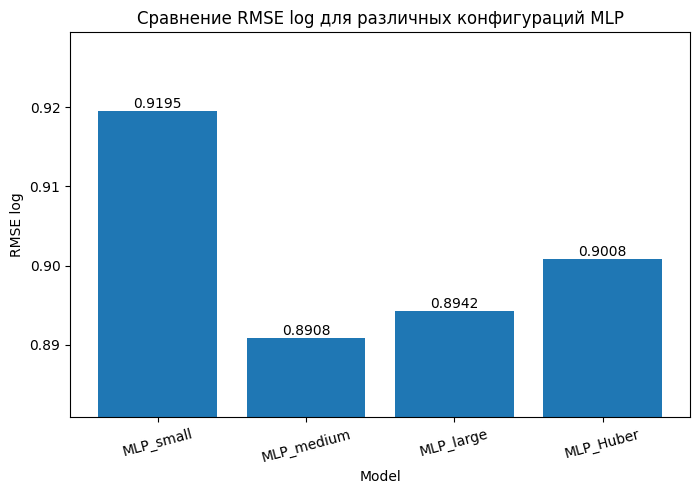

In [145]:
plt.figure(figsize=(8, 5))

bars = plt.bar(results_df["model_name"], results_df["rmse_log"])

plt.xlabel("Model")
plt.ylabel("RMSE log")
plt.title("Сравнение RMSE log для различных конфигураций MLP")
plt.xticks(rotation=15)

y_min = results_df["rmse_log"].min() - 0.01
y_max = results_df["rmse_log"].max() + 0.01
plt.ylim(y_min, y_max)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()

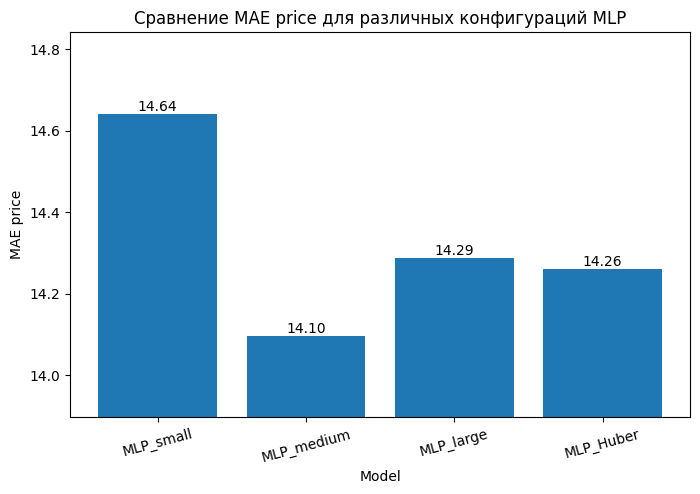

In [147]:
plt.figure(figsize=(8, 5))

bars = plt.bar(results_df["model_name"], results_df["mae_price"])

plt.xlabel("Model")
plt.ylabel("MAE price")
plt.title("Сравнение MAE price для различных конфигураций MLP")
plt.xticks(rotation=15)

y_min = results_df["mae_price"].min() - 0.2
y_max = results_df["mae_price"].max() + 0.2
plt.ylim(y_min, y_max)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

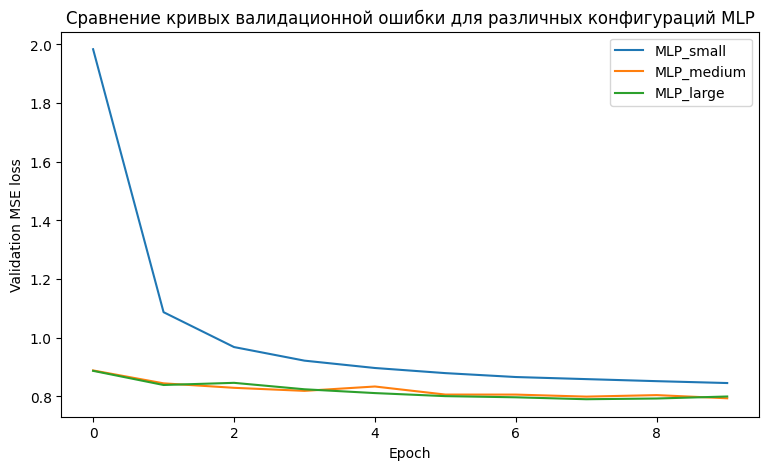

In [152]:
plt.figure(figsize=(9, 5))

plt.plot(valid_losses, label="MLP_small")
plt.plot(valid_losses_medium, label="MLP_medium")
plt.plot(valid_losses_large, label="MLP_large")

plt.xlabel("Epoch")
plt.ylabel("Validation MSE loss")
plt.title("Сравнение кривых валидационной ошибки для различных конфигураций MLP")
plt.legend()
plt.show()

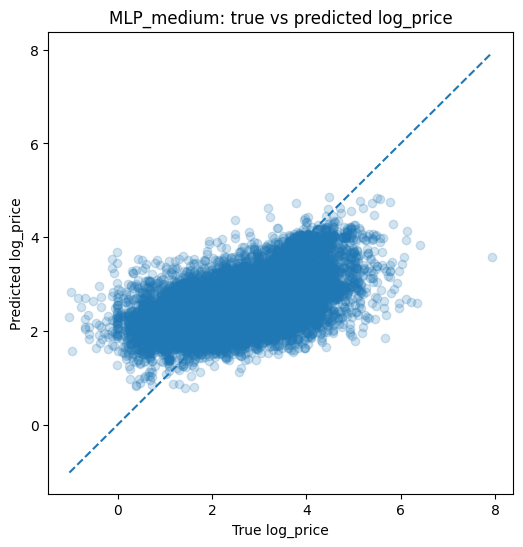

In [149]:
plt.figure(figsize=(6, 6))
plt.scatter(valid_targets_medium, valid_preds_medium, alpha=0.2)

min_val = min(valid_targets_medium.min(), valid_preds_medium.min())
max_val = max(valid_targets_medium.max(), valid_preds_medium.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("True log_price")
plt.ylabel("Predicted log_price")
plt.title("MLP_medium: true vs predicted log_price")
plt.show()

Модель ловит общий тренд, но сжимает предсказания к средним значениям. На графике видно, что дорогие товары модель часто недооценивает, а дешёвые может переоценивать

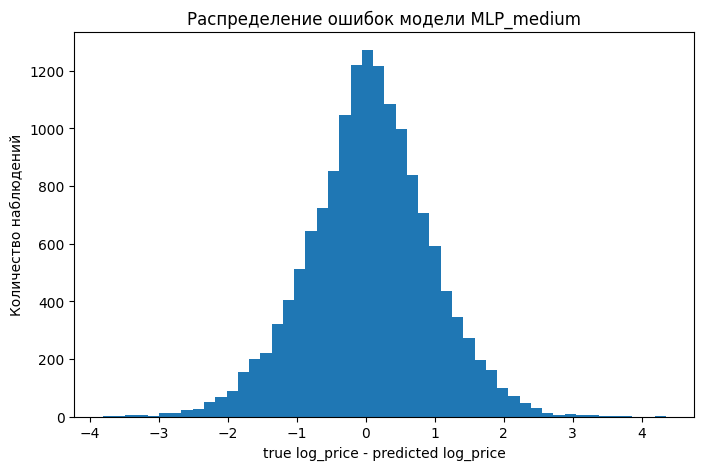

In [150]:
residuals_medium = valid_targets_medium - valid_preds_medium

plt.figure(figsize=(8, 5))
plt.hist(residuals_medium, bins=50)
plt.xlabel("true log_price - predicted log_price")
plt.ylabel("Количество наблюдений")
plt.title("Распределение ошибок модели MLP_medium")
plt.show()

ошибки примерно центрированы около нуля, значит модель не имеет сильного постоянного сдвига в одну сторону. Но хвосты есть, значит на части товаров ошибки остаются большими

MLP_medium показала лучшие значения по метрикам RMSE log, MAE log и MAE price. Увеличение архитектуры до MLP_large не улучшило результат. По нашему мнению так произошло из-за избыточной сложности. Для данной табличной задачи оптимальной оказалась средняя архитектура с BatchNorm и Dropout

Сохраним лучшую модель

In [151]:
import json
import joblib

os.makedirs("notebooks/MLP", exist_ok=True)

torch.save(model_medium.state_dict(), "notebooks/MLP/mlp_medium.pt")

joblib.dump(scaler, "notebooks/MLP/scaler.pkl")

with open("notebooks/MLP/feature_columns.json", "w") as f:
    json.dump(X.columns.tolist(), f)

results_df.to_csv("notebooks/MLP/mlp_results.csv", index=False)